# 03 — Feature Engineering & Classification Target
Build all features and create the binary classification target.
Everything needed for modelling lives in `gold_silver_final.csv`.


In [ ]:
from google.colab import files
files.upload()

Saving gold_silver_garch.csv to gold_silver_garch.csv


{'gold_silver_garch.csv': b'Date,ID_Column,usd_idx,gold,silver,interest,vix,au_returns,ag_returns,au_vol,ag_vol,au_mean,ag_mean,garch_vol_au,garch_vol_ag,vol_regime_au,vol_regime_ag,period_regime\n2010-03-03,0,79.9800033569336,1142.699951171875,17.30900001525879,3.625,18.82999992370605,0.0050885588128825,0.0154283259825429,0.0145459812484393,0.0246074143869183,0.0016277212453685,0.0018398202514242,0.008472845013920738,0.014058568699678588,low_vol,low_vol,pre_covid\n2010-03-04,1,80.55999755859375,1132.5999755859375,17.1560001373291,3.6059999465942383,18.71999931335449,-0.0088779872982455,-0.0088786236664527,0.0145230917008571,0.0247046941426067,0.0006433939642808,0.0011802801490433,0.008367325992788378,0.014231431053326131,low_vol,low_vol,pre_covid\n2010-03-05,2,80.43000030517578,1134.800048828125,17.36199951171875,3.681999921798706,17.420000076293945,0.0019406138387151,0.0119359071866943,0.0144589097481258,0.0240076177576615,0.0009921887214231,0.0029764522836817,0.008456758345988752,0.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('gold_silver_garch.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Loaded: {df.shape} | {df.index[0].date()} → {df.index[-1].date()}")
print(f"Columns: {df.columns.tolist()}")

Loaded: (4092, 17) | 2010-03-03 → 2026-06-12
Columns: ['ID_Column', 'usd_idx', 'gold', 'silver', 'interest', 'vix', 'au_returns', 'ag_returns', 'au_vol', 'ag_vol', 'au_mean', 'ag_mean', 'garch_vol_au', 'garch_vol_ag', 'vol_regime_au', 'vol_regime_ag', 'period_regime']


## 1. Lag Features — Return History

In [ ]:
for lag in [1, 2, 5]:
    df[f'au_lag{lag}'] = df['au_returns'].shift(lag)
    df[f'ag_lag{lag}'] = df['ag_returns'].shift(lag)

print("Lag features created: au_lag1/2/5, ag_lag1/2/5")

Lag features created: au_lag1/2/5, ag_lag1/2/5


## 2. Macro Momentum Features

In [ ]:
df['vix_chg']      = df['vix'].pct_change()       # VIX day-over-day % change
df['usd_chg']      = df['usd_idx'].pct_change()   # USD momentum
df['interest_chg'] = df['interest'].diff()         # Rate change in bps

print("Macro momentum features created: vix_chg, usd_chg, interest_chg")

Macro momentum features created: vix_chg, usd_chg, interest_chg


## 3. Gold-Silver Ratio (z-scored)

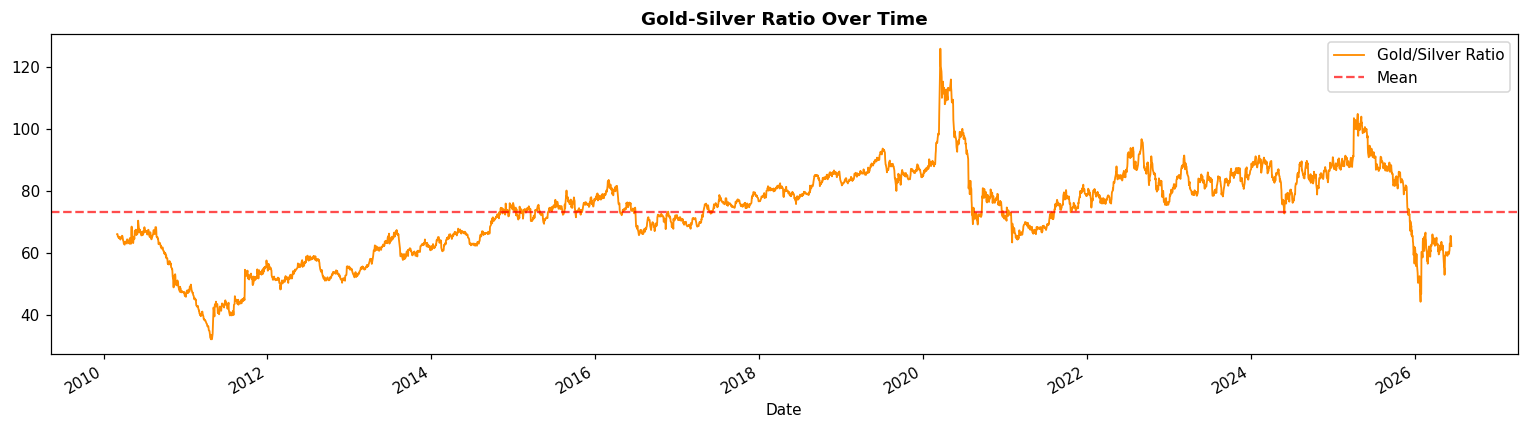

Ratio range: 32.0 – 125.9
Historical mean: 73.2


In [ ]:
df['au_ag_ratio']   = df['gold'] / df['silver']
df['au_ag_ratio_z'] = (df['au_ag_ratio'] - df['au_ag_ratio'].mean()) / df['au_ag_ratio'].std()

plt.figure(figsize=(14, 4))
df['au_ag_ratio'].plot(color='darkorange', linewidth=1.2, label='Gold/Silver Ratio')
plt.title('Gold-Silver Ratio Over Time', fontweight='bold')
plt.axhline(df['au_ag_ratio'].mean(), color='red', linestyle='--', alpha=0.7, label='Mean')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Ratio range: {df['au_ag_ratio'].min():.1f} – {df['au_ag_ratio'].max():.1f}")
print(f"Historical mean: {df['au_ag_ratio'].mean():.1f}")

## 4. GARCH Vol Lags

In [ ]:
df['garch_vol_au_lag1'] = df['garch_vol_au'].shift(1)
df['garch_vol_ag_lag1'] = df['garch_vol_ag'].shift(1)
print("GARCH lag features created: garch_vol_au_lag1, garch_vol_ag_lag1")

GARCH lag features created: garch_vol_au_lag1, garch_vol_ag_lag1


## 5. Classification Target — Next-Day Direction

In [ ]:
# TARGET: 1 = next day return is positive (UP), 0 = negative or zero (DOWN)
df['target_au'] = (df['au_returns'].shift(-1) > 0).astype(int)
df['target_ag'] = (df['ag_returns'].shift(-1) > 0).astype(int)

# Drop last row (no target available) and all NaN from lags
df = df.dropna()

print("Target Distribution:")
print(f"  Gold  UP days: {df['target_au'].mean():.1%}  DOWN days: {(1-df['target_au'].mean()):.1%}")
print(f"  Silver UP days: {df['target_ag'].mean():.1%}  DOWN days: {(1-df['target_ag'].mean()):.1%}")

Target Distribution:
  Gold  UP days: 52.8%  DOWN days: 47.2%
  Silver UP days: 51.9%  DOWN days: 48.1%


## 6. Final Feature Set

In [ ]:
FEATURES = [
    # Return series
    'au_returns', 'ag_returns',
    # Rolling stats (already in raw data)
    'au_vol', 'ag_vol', 'au_mean', 'ag_mean',
    # Lag features
    'au_lag1', 'au_lag2', 'au_lag5',
    'ag_lag1', 'ag_lag2', 'ag_lag5',
    # Macro
    'vix', 'interest', 'usd_idx',
    'vix_chg', 'usd_chg', 'interest_chg',
    # GARCH volatility (conditional)
    'garch_vol_au', 'garch_vol_ag',
    'garch_vol_au_lag1', 'garch_vol_ag_lag1',
    # Ratio
    'au_ag_ratio_z'
]
print(f"Total features: {len(FEATURES)}")
print("\nFeature list:")
for f in FEATURES:
    print(f"  {f}")

Total features: 23

Feature list:
  au_returns
  ag_returns
  au_vol
  ag_vol
  au_mean
  ag_mean
  au_lag1
  au_lag2
  au_lag5
  ag_lag1
  ag_lag2
  ag_lag5
  vix
  interest
  usd_idx
  vix_chg
  usd_chg
  interest_chg
  garch_vol_au
  garch_vol_ag
  garch_vol_au_lag1
  garch_vol_ag_lag1
  au_ag_ratio_z


## 7. Train / Test Split — FIXED 70/30

In [ ]:
SPLIT = 0.70
split_idx = int(len(df) * SPLIT)
train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

print(f"Train: {train.index[0].date()} → {train.index[-1].date()} | {len(train)} rows")
print(f"Test : {test.index[0].date()} → {test.index[-1].date()} | {len(test)} rows")
print(f"\nTest period covers:")
print(f"  Period regimes: {test['period_regime'].value_counts().to_dict()}")
print(f"  Vol regimes (Au): {test['vol_regime_au'].value_counts().to_dict()}")
print(f"  Vol regimes (Ag): {test['vol_regime_ag'].value_counts().to_dict()}")

Train: 2010-03-10 → 2021-07-23 | 2860 rows
Test : 2021-07-26 → 2026-06-12 | 1227 rows

Test period covers:
  Period regimes: {'post_covid': 1115, 'covid': 112}
  Vol regimes (Au): {'high_vol': 719, 'low_vol': 508}
  Vol regimes (Ag): {'high_vol': 718, 'low_vol': 509}


## 8. Feature Correlation with Target

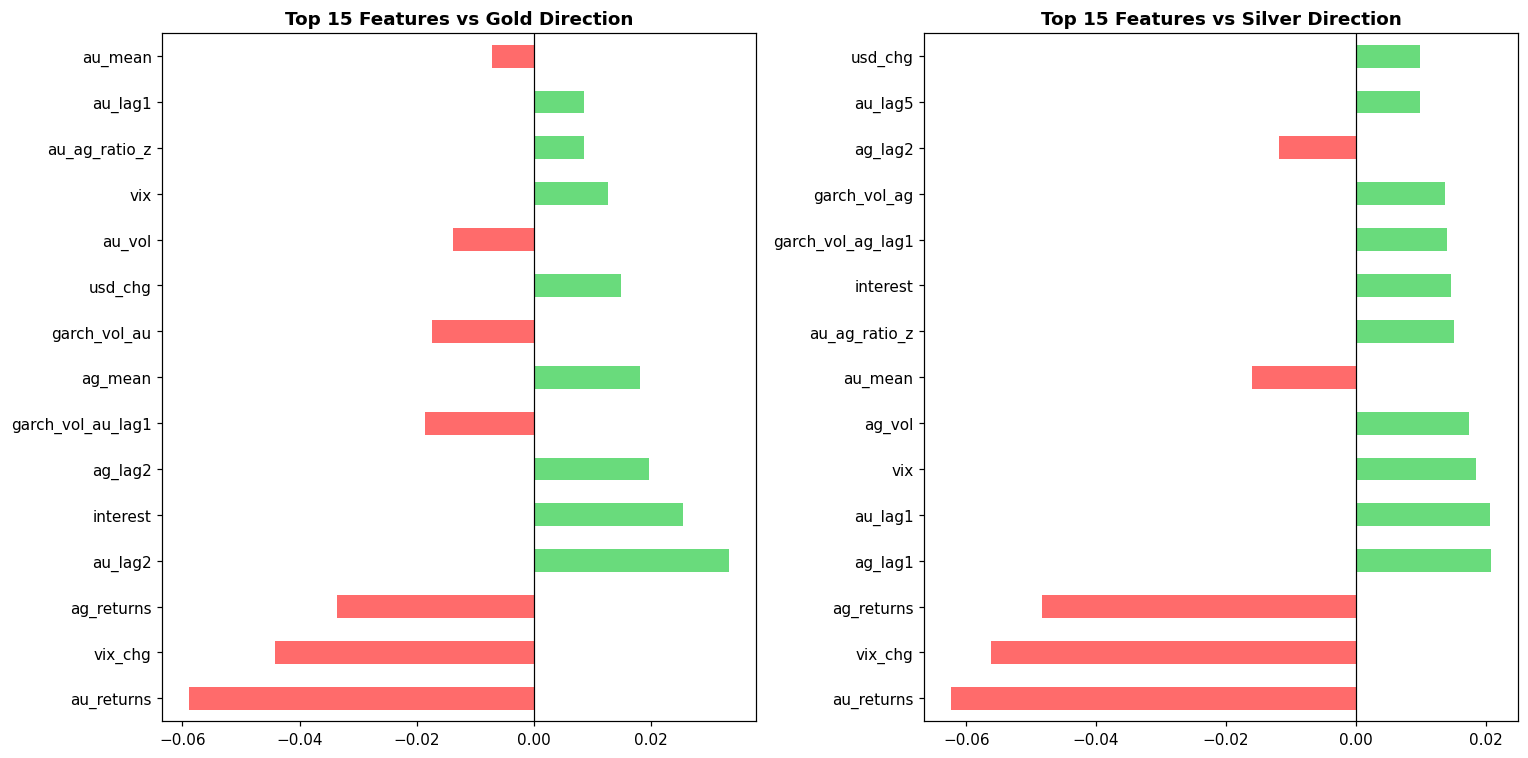

In [ ]:
corr_au = df[FEATURES + ['target_au']].corr()['target_au'][FEATURES].sort_values(key=abs, ascending=False)
corr_ag = df[FEATURES + ['target_ag']].corr()['target_ag'][FEATURES].sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

corr_au.head(15).plot(kind='barh', ax=axes[0], color=['#FF6B6B' if v < 0 else '#69DB7C' for v in corr_au.head(15)])
axes[0].set_title('Top 15 Features vs Gold Direction', fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)

corr_ag.head(15).plot(kind='barh', ax=axes[1], color=['#FF6B6B' if v < 0 else '#69DB7C' for v in corr_ag.head(15)])
axes[1].set_title('Top 15 Features vs Silver Direction', fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 9. Save Final Dataset

In [ ]:
df.to_csv('gold_silver_final.csv')
print("Saved: gold_silver_final.csv")
print(f"Final shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Saved: gold_silver_final.csv
Final shape: (4087, 32)
Columns: ['ID_Column', 'usd_idx', 'gold', 'silver', 'interest', 'vix', 'au_returns', 'ag_returns', 'au_vol', 'ag_vol', 'au_mean', 'ag_mean', 'garch_vol_au', 'garch_vol_ag', 'vol_regime_au', 'vol_regime_ag', 'period_regime', 'au_lag1', 'ag_lag1', 'au_lag2', 'ag_lag2', 'au_lag5', 'ag_lag5', 'vix_chg', 'usd_chg', 'interest_chg', 'au_ag_ratio', 'au_ag_ratio_z', 'garch_vol_au_lag1', 'garch_vol_ag_lag1', 'target_au', 'target_ag']


In [ ]:
files.download("gold_silver_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>